# (연구) HST example 3

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [논문연구]

### 실험환경 

In [11]:
!conda env list

# conda environments:
#
base                     /home/cgb2/anaconda3
py39r40               *  /home/cgb2/anaconda3/envs/py39r40



### import

In [108]:
## 1. remove trash
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('image', cmap='Greys')
import rpy2 
%load_ext rpy2.ipython
%run pybase
%run heavysnow 
plt.style.use('ggplot')

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


### load data

In [109]:
n=23
f=np.array(pd.read_csv("2021-08-15-MCU-ticket.csv").Worldwide)/1000000
V=np.array(pd.read_csv("2021-08-15-MCU-ticket.csv").Film)
W=np.array(pd.read_csv("2021-08-15-MCU-weights.csv",index_col=0))-np.eye(n,n)

### HST

In [110]:
gs=GraphSignal(V,W,f)
hst=HeavysnowTransform(gs)
hst.snow(tau=80000,b=1)

HST (tau= 80000, b=1)
80000/80000
HST completed and all history is recorded.


/home/cgb2/Dropbox/01_yechan/_notebooks/heavysnow.py:11: RuntimeWarning: invalid value encountered in true_divide


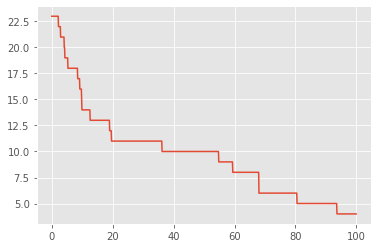

In [111]:
def choose_theta(maxtheta=100):
    y=[]
    x=np.arange(start=0.01,stop=maxtheta,step=0.1)
    for i in range(len(x)):
        hst.adjustingtheta(x[i]) 
        gs=GraphSignal(V,hst.snowweight,f)
        spa=SpectralAnalysis(gs)
        spa.graphFouriertransform()
        spa.decompose()        
        y.append(sum(abs(spa.lamb)<0.001))
    plt.plot(x,y)
choose_theta()   

In [112]:
hst.adjustingtheta(100)

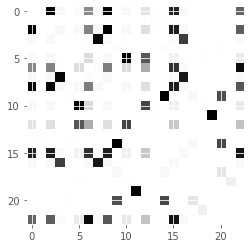

In [113]:
plt.imshow(hst.snowweight)

### R 환경으로.. 

In [114]:
import rpy2 
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [115]:
n=hst.n 
V=hst.V
f=hst.f 
WEuclid= hst.euclidweight
Wgraph= (hst.graphweight+hst.graphweight.T)/2
Whst= hst.snowweight
W= hst.graphweight

In [116]:
%R -i n
%R -i V
%R -i f
%R -i WEuclid
%R -i Wgraph
%R -i Whst
%R -i W

### 유클리드와 그래프도메인의 정보를 플랏. 

In [117]:
%%R 
source('heavysnow.R')
df<-tibble(V)
df$f<-as.vector(f)
df$divlink<-0
df$conlink<-0
df$link<-0
for(i in 1:23){
    df$divlink[i]<-sum(W[i,])
    df$conlink[i]<-sum(W[,i])
    df$link[i]<-(sum(W[i,])+sum(W[,i]))/2
}
df$type<-rep('solo',23)
df[V %in% c("The Avengers" ,"Avengers: Age of Ultron","Captain America: Civil War","Avengers: Infinity War","Avengers: Endgame"),'type']='multi'
df

# A tibble: 23 × 6
   V                                       f divlink conlink  link type 
   <chr>                               <dbl>   <dbl>   <dbl> <dbl> <chr>
 1 Iron Man                             585.    4      2.52  3.26  solo 
 2 The Incredible Hulk                  263.    1      0.295 0.647 solo 
 3 Iron Man 2                           624.    4.15   3.11  3.63  solo 
 4 Thor                                 449.    2.56   2.24  2.40  solo 
 5 Captain America: The First Avenger   371.    1.75   0.948 1.35  solo 
 6 The Avengers                        1519.    4.65   4.33  4.49  multi
 7 Iron Man 3                          1215.    3.2    1.69  2.45  solo 
 8 Thor: The Dark World                 645.    2.41   2.15  2.28  solo 
 9 Captain America: The Winter Soldier  714.    3.27   2.46  2.86  solo 
10 Guardians of the Galaxy              773.    1.63   1.21  1.42  solo 
# … with 13 more rows


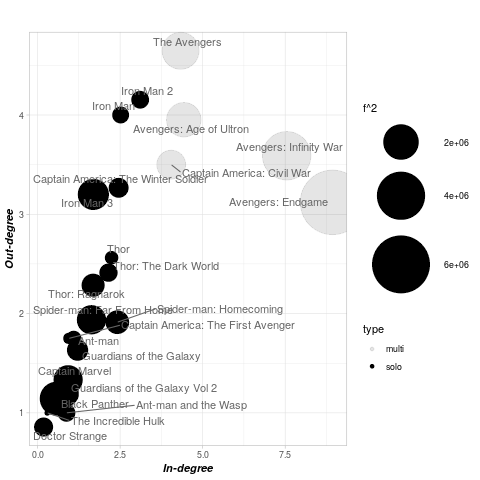

In [137]:
%%R 
p1<-ggplot(df)+
    geom_point(aes(x=conlink,y=divlink,size=f**2,alpha=type))+
    theme_light()+
    geom_text_repel(aes(x=conlink,y=divlink,label=V),col="gray40")+
    #geom_density2d(aes(x=conlink,y=divlink,fill=f,color=f))+
    ylab("Out-degree")+xlab("In-degree")+
    ggtitle("")+
    theme(plot.title=element_text(face="bold.italic",size=rel(2)))+
    theme(axis.title.x=element_text(face=4,size=rel(1)))+
    theme(axis.title.y=element_text(face=4,size=rel(1)))+
    scale_size(range=c(2,30))
    #theme(legend.position = "none")+
show(p1)
ggsave(plot=p1,"./2021-12-10-p1.pdf",width=15,height=10)

# p1_<-ggplot(dat)+geom_point(aes(x=f,y=divlink),size=3)+theme_light()+
#         geom_text_repel(aes(x=f,y=divlink,label=V),col="gray40")+
#         ylab("Out-degree")+xlab("Box office record")+
#         geom_hline(aes(yintercept=2),col=2,lty=2,lwd=0.5)+
#         geom_vline(aes(xintercept=1000),col=2,lty=2,lwd=0.5)+
#         ggtitle("(a)")+theme(plot.title=element_text(face="bold.italic",size=rel(2)))+
#         theme(axis.title.x=element_text(face=4,size=rel(1)))+
#         theme(axis.title.y=element_text(face=4,size=rel(1)))
# p2_<-ggplot(dat)+geom_point(aes(x=f,y=conlink),size=3)+theme_light()+
#         geom_text_repel(aes(x=f,y=conlink,label=V),col="gray40")+
#         ylab("In-degree")+xlab("Box office record")+
#         geom_hline(aes(yintercept=3.75),col=2,lty=2,lwd=0.5)+
#         geom_vline(aes(xintercept=1000),col=2,lty=2,lwd=0.5)+
#         ggtitle("(b)")+theme(plot.title=element_text(face="bold.italic",size=rel(2)))+
#         theme(axis.title.x=element_text(face=4,size=rel(1)))+
#         theme(axis.title.y=element_text(face=4,size=rel(1)))
#p1<-grid.arrange(p1_,p2_,ncol=2)
#ggsave(plot=p1,"./fig/p1.pdf",width=9,height=4.5)

In [119]:
%%R 
df

# A tibble: 23 × 6
   V                                       f divlink conlink  link type 
   <chr>                               <dbl>   <dbl>   <dbl> <dbl> <chr>
 1 Iron Man                             585.    4      2.52  3.26  solo 
 2 The Incredible Hulk                  263.    1      0.295 0.647 solo 
 3 Iron Man 2                           624.    4.15   3.11  3.63  solo 
 4 Thor                                 449.    2.56   2.24  2.40  solo 
 5 Captain America: The First Avenger   371.    1.75   0.948 1.35  solo 
 6 The Avengers                        1519.    4.65   4.33  4.49  multi
 7 Iron Man 3                          1215.    3.2    1.69  2.45  solo 
 8 Thor: The Dark World                 645.    2.41   2.15  2.28  solo 
 9 Captain America: The Winter Soldier  714.    3.27   2.46  2.86  solo 
10 Guardians of the Galaxy              773.    1.63   1.21  1.42  solo 
# … with 13 more rows


### gfft 수행하고 결과를 저장함. 

In [131]:
%%R 
g1<-gfft(f,WEuclid)
g2<-gfft(f,Wgraph)
g3<-gfft(f,Whst)

### 아이겐플랏 


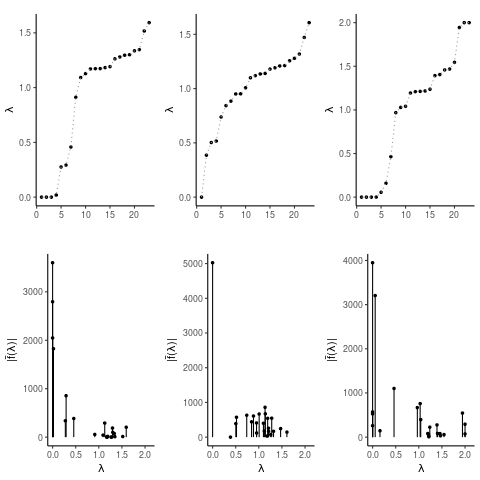

In [133]:
%%R 
library(gridExtra)
e1<-eigenplot(g1)+theme(plot.title=element_text(face="bold.italic",size=rel(1)))
e2<-eigenplot(g2)+theme(plot.title=element_text(face="bold.italic",size=rel(1)))
e3<-eigenplot(g3)+theme(plot.title=element_text(face="bold.italic",size=rel(1)))
s1<-specplot(g1)
s2<-specplot(g2)
s3<-specplot(g3)
p2<-grid.arrange(e1,e2,e3,s1,s2,s3,nrow=2)
ggsave(plot=p2,"./2021-12-10-p2.pdf",width=5,height=3)

### 분해 

In [122]:
%%R
d1<-decompose(f,WEuclid,V=V) # 0, 35000, 60000, 80000
d2<-decompose(f,Wgraph,V=V) # 0, 35000, 60000, 80000
d3<-decompose(f,Whst,V=V) # 0, 35000, 60000, 80000

d1$case<-"Euclid"
d2$case<-"Graph"
d3$case<-"HST"
.df2 <-rbind(d1,d2,d3)
.df2 %>% group_by(case,eigenvectorindex) #%>% mutate(textsize= 10*(abs(fhat)>70))
df2=merge(df, .df2 %>% group_by(case,eigenvectorindex) %>% mutate(textsize= 10*(abs(fhat)>70))) %>% as_tibble
df2

# A tibble: 1,587 × 12
   V           f divlink conlink  link type  Vindex eigenvectorindex     fhat
   <chr>   <dbl>   <dbl>   <dbl> <dbl> <chr>  <int>            <dbl>    <dbl>
 1 Ant-man  519.    1.75    1.10  1.42 solo      12                1  554.   
 2 Ant-man  519.    1.75    1.10  1.42 solo      12                6 -142.   
 3 Ant-man  519.    1.75    1.10  1.42 solo      12               17   -1.52 
 4 Ant-man  519.    1.75    1.10  1.42 solo      12                5   61.6  
 5 Ant-man  519.    1.75    1.10  1.42 solo      12               12    0.274
 6 Ant-man  519.    1.75    1.10  1.42 solo      12               15    0.328
 7 Ant-man  519.    1.75    1.10  1.42 solo      12                8   28.4  
 8 Ant-man  519.    1.75    1.10  1.42 solo      12               22   -0.843
 9 Ant-man  519.    1.75    1.10  1.42 solo      12               18   -6.37 
10 Ant-man  519.    1.75    1.10  1.42 solo      12                2  188.   
# … with 1,577 more rows, and 3 more vari

In [163]:
%%R -r 150 -w 2000 -h 5500
        
p3<-ggplot(data=filter(df2,eigenvectorindex %in% 1:23, case=='HST'))+
    geom_col(aes(x=Vindex,y=fhat,fill=fhat>0),width=0.7)+
    geom_text_repel(aes(x=Vindex,y=fhat,label=V,size=textsize),col=1,fontface=4,alpha=0.8,segment.size=0.2,segment.color="gray60",min.segment.length=5,hjust=0.1)+
    scale_radius(range = c(0,1.8))+
    guides(size=FALSE)+
    facet_wrap("eigenvectorindex")+
    geom_hline(aes(yintercept=0),col="gray60",lty=2)+
    xlab("")+ylab("")+guides(fill=FALSE)+
    theme(axis.text.x=element_text(angle=85,hjust=1,vjust=1,face=4,size=rel(0.7),colour="gray60"))+
    theme_light()+
    theme(strip.text.x = element_text(size = 10, color = "black", face = "bold.italic"))+
    theme(strip.text.y = element_text(size = 10, color = "black", face = "bold.italic"))+
    theme(plot.title=element_text(face="bold.italic",size=rel(1.5)))
show(p3)
ggsave(plot=p3,"./2021-12-10-p3.pdf",width=10,height=15)

RParsingError: Parsing status not OK - PARSING_STATUS.PARSE_ERROR